In [1]:
import sys
from pathlib import Path

# Ensure repo root is on sys.path
repo_root = Path.cwd().resolve()
while repo_root.name and not (repo_root / "pyproject.toml").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# Ensure this example dir is on sys.path so we can import heatsink_tutorial
example_dir = str(repo_root / "examples" / "heatflow" / "heatsink")
if example_dir not in sys.path:
    sys.path.insert(0, example_dir)

import heatsink_tutorial as ht

import matplotlib
%matplotlib inline

# Check server
assert ht.server_is_healthy(), "py2femm server not running on localhost:8082"
print("Server OK")

Server OK


## 1. Geometry


=== 1. Dimensions ===
  Base:     35.0 x 5.0 mm
  Fins:     5 x 1.5 mm wide, 20.0 mm tall, gap = 6.875 mm
  Contact:  4.0 mm centered (15.5 - 19.5 mm)
  Depth:    100.0 mm
  Power:    10.0 W  ->  qs = 25000 W/m^2
  Convection: h = 10.0 W/(m^2*K), T_amb = 298.0 K

24 nodes, 24 segments


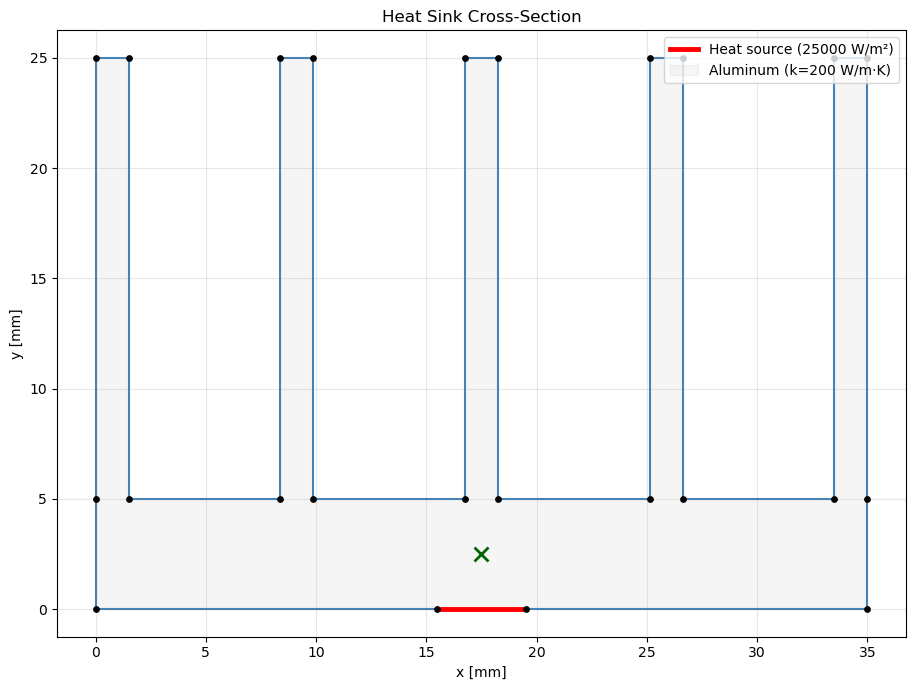

In [2]:
ht.print_dimensions()
nodes = ht.build_outline_nodes()
geo, lines = ht.build_geometry(nodes)
print(f"\n{len(nodes)} nodes, {len(lines)} segments")
ht.plot_geometry(nodes, lines)

## 2. Run FEMM (5-fin baseline)

In [3]:
problem = ht.build_femm_problem(nodes, geo)
lua_script = ht.get_lua_script(problem)
print(f"Lua: {len(lua_script)} chars, {lua_script.count(chr(10))} lines")

csv_data = ht.run_femm(lua_script)
print(f"\nRaw output:\n{csv_data.strip()}")

Lua: 4867 chars, 145 lines
  Connected (mode: remote)
  Completed in 4.1s

Raw output:
AverageTemperature_K = 334.3717142644356
PY2FEMM_DONE


## 3. Results

Average temperature:  334.4 K  (61.2 °C)
Thermal resistance:   3.64 K/W


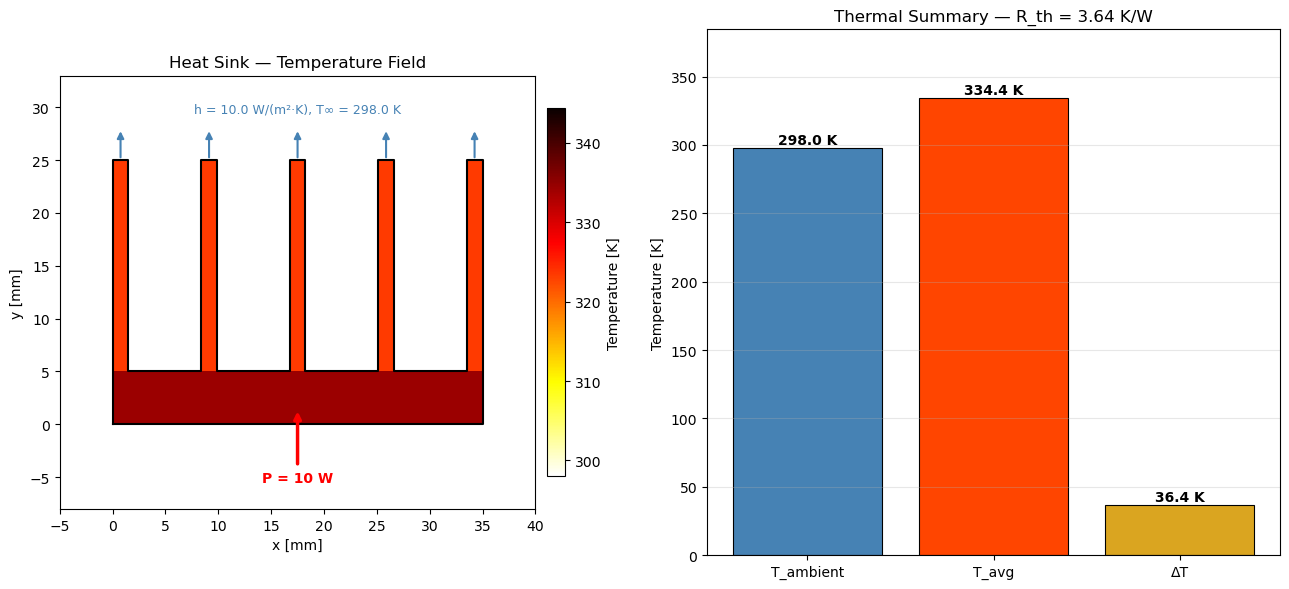

In [4]:
results = ht.parse_results(csv_data)
avg_T, R_th = ht.validate_results(results)

print(f"Average temperature:  {avg_T:.1f} K  ({avg_T - 273.15:.1f} \u00b0C)")
print(f"Thermal resistance:   {R_th:.2f} K/W")

ht.plot_results(nodes, avg_T, R_th)

## 4. Parametric Sweep (3, 5, 7, 9 fins)

3 fins: T_avg = 349.2 K, R_th = 5.12 K/W
5 fins: T_avg = 334.4 K, R_th = 3.64 K/W
7 fins: T_avg = 326.2 K, R_th = 2.82 K/W
9 fins: T_avg = 321.0 K, R_th = 2.30 K/W


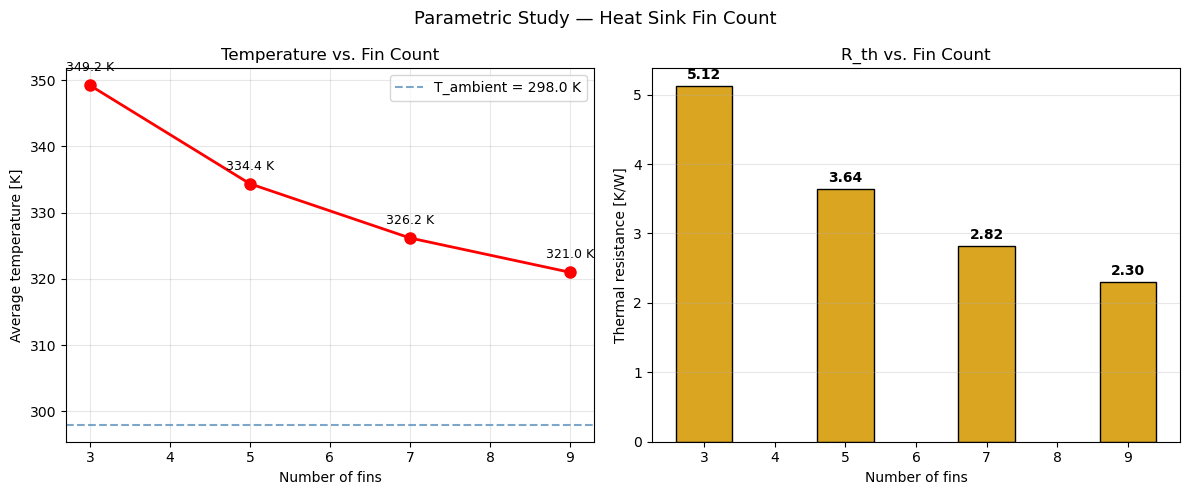

In [5]:
from py2femm.client import FemmClient

client = FemmClient(mode="remote", url="http://localhost:8082")
parametric = {}

for nf in [3, 5, 7, 9]:
    script = ht.build_parametric(nf)
    res = client.run(script, timeout=120)
    assert res.error is None, f"{nf}-fin failed: {res.error}"
    assert res.csv_data, f"{nf}-fin: no CSV"
    parsed = ht.parse_results(res.csv_data)
    T = parsed["AverageTemperature_K"]
    parametric[nf] = T
    print(f"{nf} fins: T_avg = {T:.1f} K, R_th = {(T - ht.T_AMB) / ht.P:.2f} K/W")

ht.plot_parametric(parametric)